## Session 20 - Optional Task (HousePrediction Dataset)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [39]:
# Load dataset
df = pd.read_csv("House_Price_Prediction.csv")

# Display first 5 rows
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [59]:
print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (4551, 18)

Column Names:
Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'city', 'statezip', 'country', 'year',
       'month'],
      dtype='object')

Data Types:
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
city              object
statezip          object
country           object
year               int32
month              int32
dtype: object


In [41]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())

# Duplicate Rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

Duplicate Rows: 0


In [42]:
# Remove missing values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

New Shape: (4600, 18)


In [43]:
print(df.describe())

print("\nPrice Statistics")
print("Minimum :", df["price"].min())
print("Maximum :", df["price"].max())
print("Mean    :", df["price"].mean())
print("Median  :", df["price"].median())

              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.346957  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.206916  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  4600.000000  4600.000000  4600.000000  4600.000000  4600.000000   
mean      1.512065     0.007174     0.240652     3.451739  1827.265435   
std       0.538288     0.084404     0.778405     0.677230   862.168977   
min       

In [45]:
# Remove houses with invalid price

df = df[df["price"] > 0]

print("Dataset Shape:", df.shape)

Dataset Shape: (4551, 18)


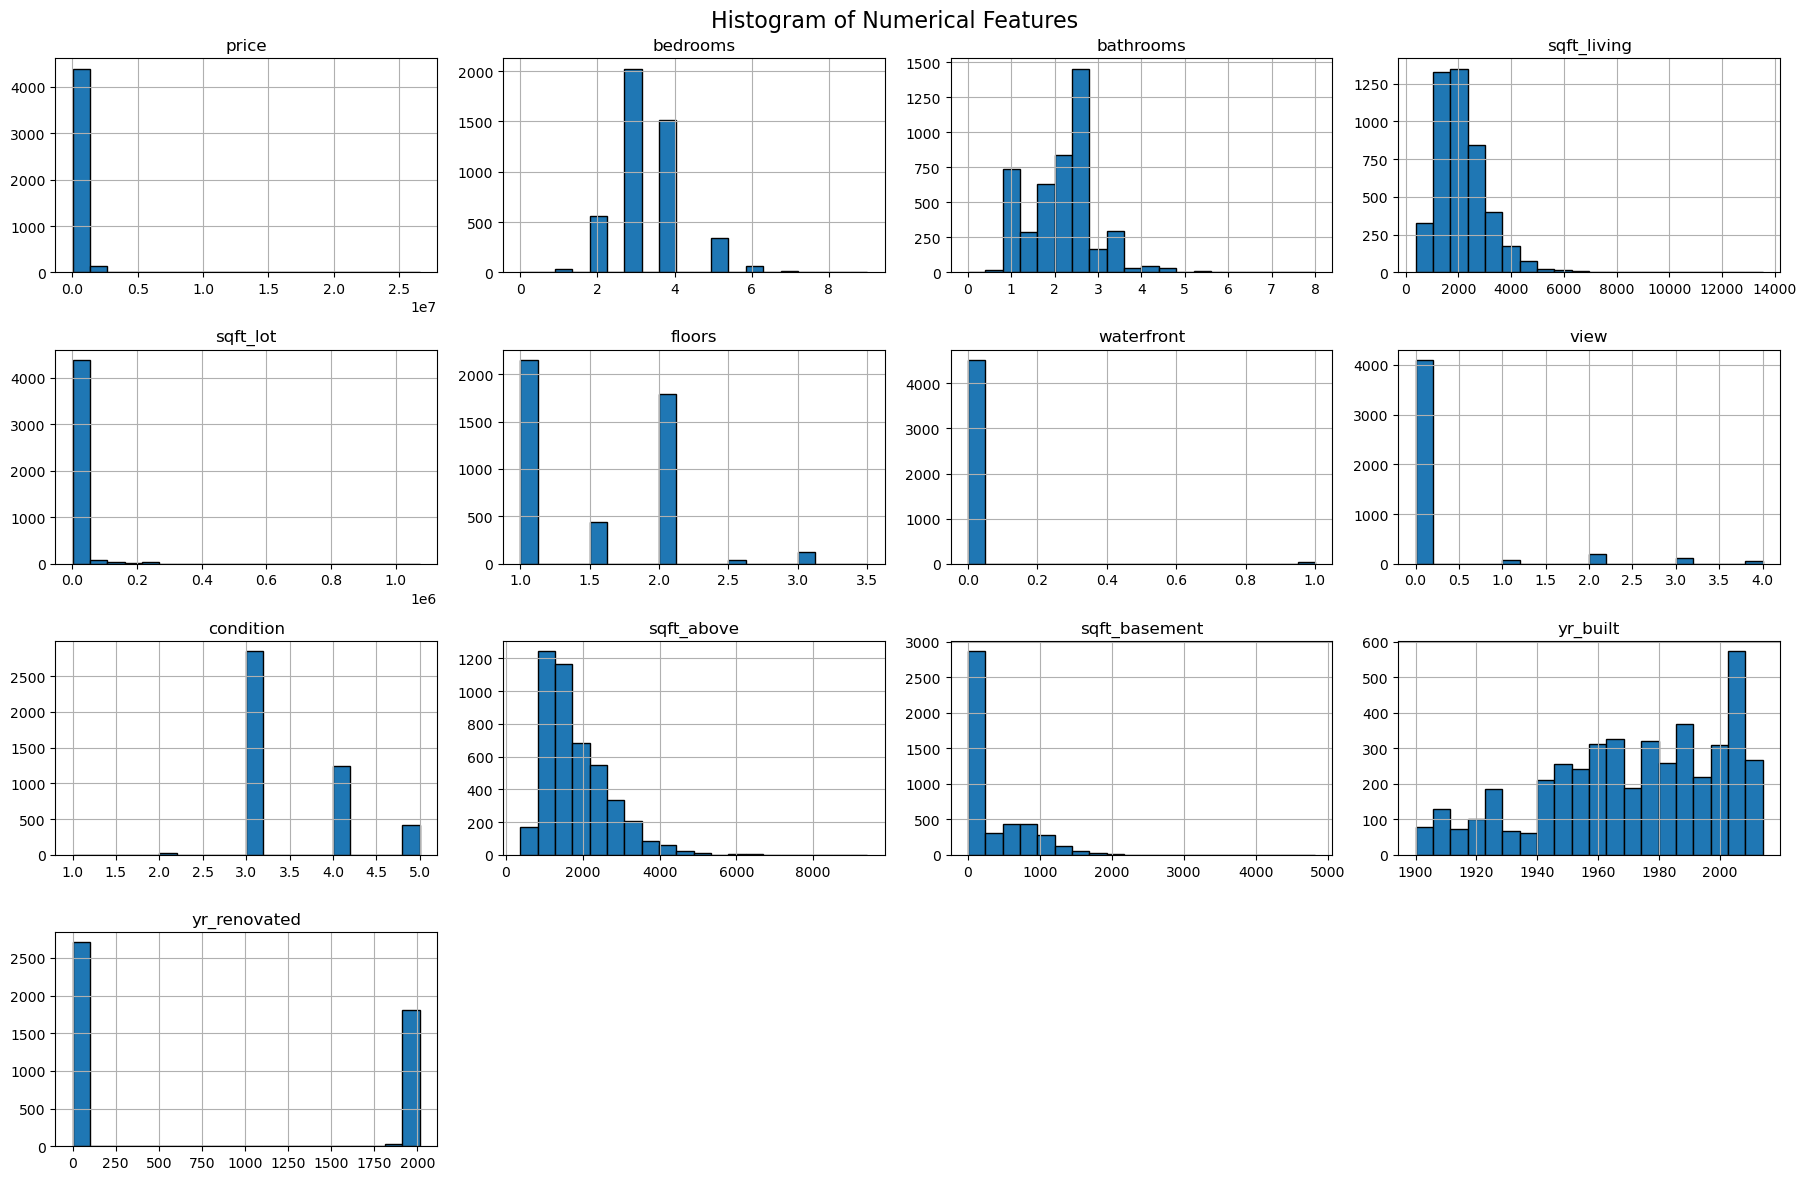

In [46]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Plot histograms
df[numeric_columns].hist(figsize=(18, 12), bins=20, edgecolor="black")

plt.suptitle("Histogram of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Categorical Columns:
['date', 'street', 'city', 'statezip', 'country']


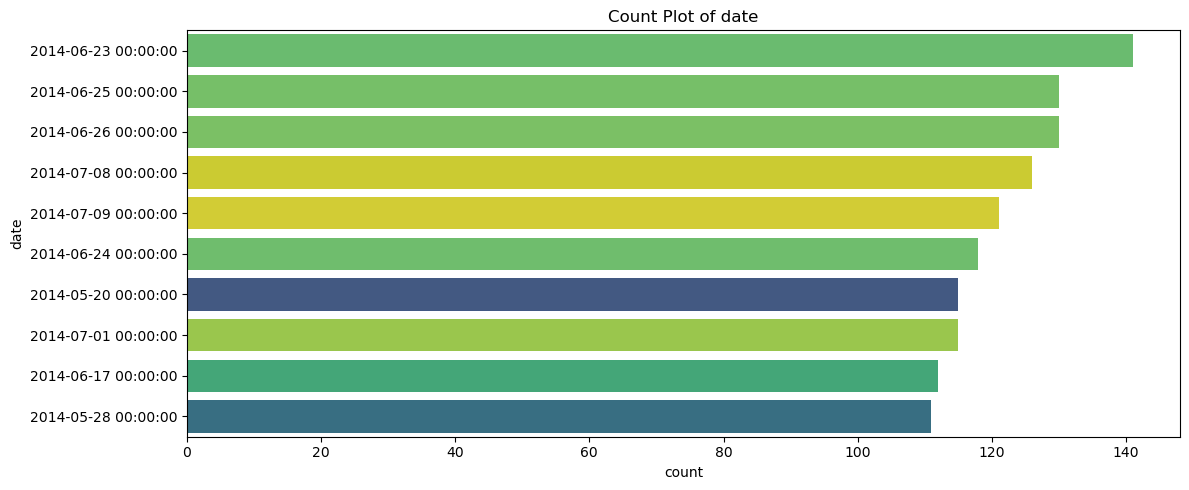

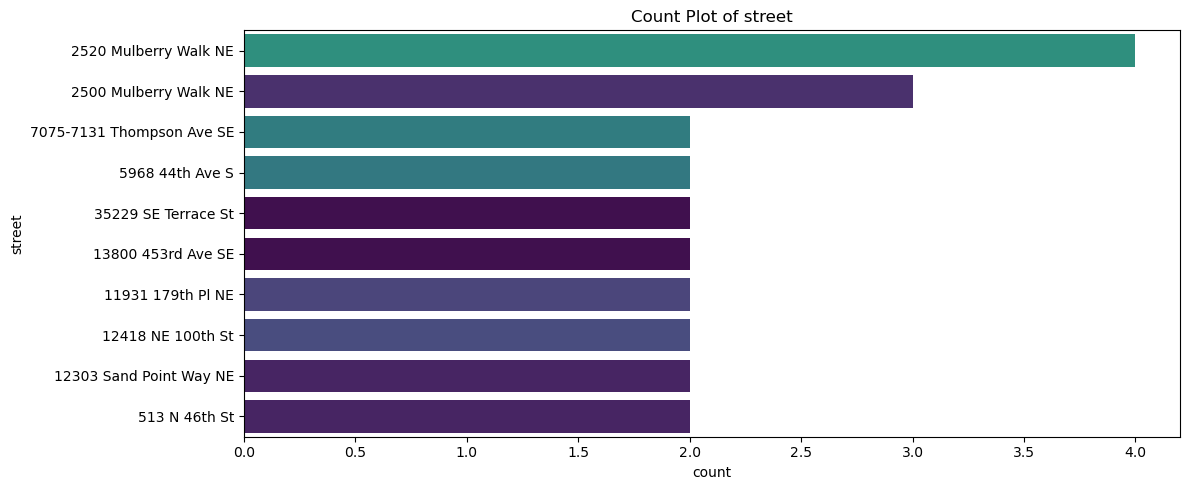

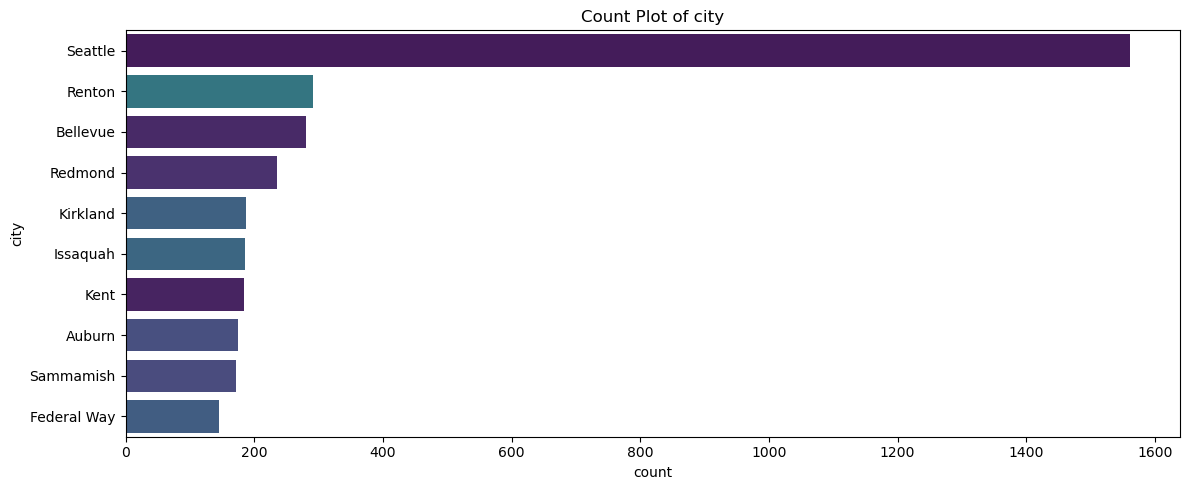

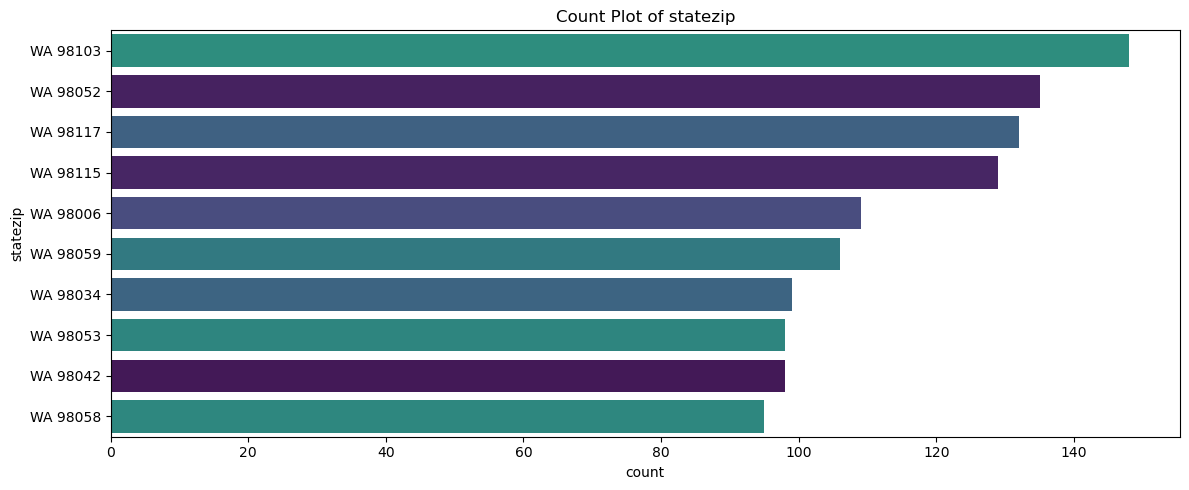

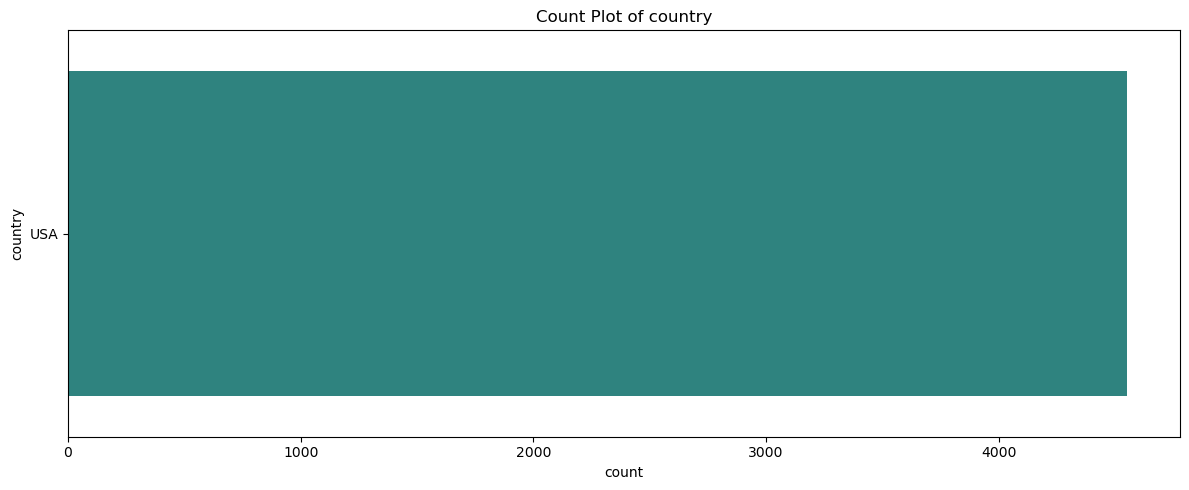

In [47]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns.tolist())

# Plot count plots
for col in categorical_columns:
    plt.figure(figsize=(12,5))

    sns.countplot(
        y=col,
        data=df,
        order=df[col].value_counts().index[:10],
        hue=col,
        palette="viridis",
        legend=False
    )

    plt.title(f"Count Plot of {col}")
    plt.tight_layout()
    plt.show()

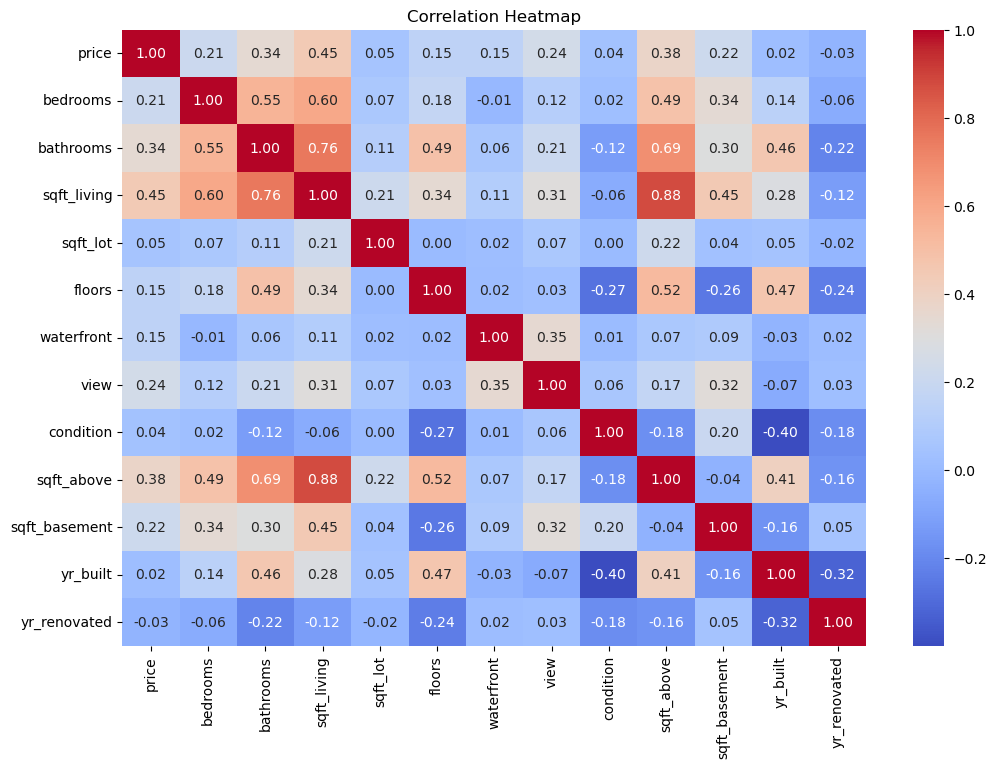

In [48]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [49]:
# Convert date into datetime format
df["date"] = pd.to_datetime(df["date"])

# Extract year and month
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,year,month
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,2014,5
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,2014,5
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,2014,5
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,2014,5
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,2014,5


In [50]:
# Drop date and street columns

df.drop(["date", "street"], axis=1, inplace=True)

df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,country,year,month
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,USA,2014,5
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,USA,2014,5
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,USA,2014,5
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,USA,2014,5
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,USA,2014,5


In [51]:
# Independent and Dependent Features

X = df.drop("price", axis=1)

y = df["price"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (4551, 17)
Shape of y: (4551,)


In [52]:
# Identify categorical columns
categorical_columns = X.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns.tolist())

# Apply One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("\nShape After Encoding:", X.shape)

X.head()

Categorical Columns:
['city', 'statezip', 'country']

Shape After Encoding: (4551, 133)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,...,False,False,False,False,False,False,False,False,False,False
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,...,False,False,False,False,False,False,False,False,False,False
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,...,False,False,False,False,False,False,False,False,False,False
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,...,False,False,False,False,False,False,False,False,False,False
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,...,False,False,False,False,False,False,False,False,False,False


In [53]:
from sklearn.preprocessing import StandardScaler

# Numerical columns
numerical_columns = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated",
    "year",
    "month"
]

# Apply Standard Scaling
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

# Display first 5 rows
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,-0.436308,-0.843810,-0.828976,-0.192527,-0.022648,-0.08146,-0.306647,-0.665622,-0.564425,-0.671413,...,False,False,False,False,False,False,False,False,False,False
1,1.774869,0.444408,1.587735,-0.160880,0.905905,-0.08146,4.920139,2.296965,1.811625,-0.065270,...,False,False,False,False,False,False,False,False,False,False
2,-0.436308,-0.199701,-0.211721,-0.080319,-0.951201,-0.08146,-0.306647,0.815672,0.126151,-0.671413,...,False,False,False,False,False,False,False,False,False,False
3,-0.436308,0.122354,-0.138487,-0.189245,-0.951201,-0.08146,-0.306647,0.815672,-0.962384,1.493385,...,False,False,False,False,False,False,False,False,False,False
4,0.669281,0.444408,-0.201259,-0.120558,-0.951201,-0.08146,-0.306647,0.815672,-0.798519,1.060425,...,False,False,False,False,False,False,False,False,False,False


In [54]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (3049, 133)
X_test Shape : (1502, 133)
y_train Shape: (3049,)
y_test Shape : (1502,)


In [55]:
# Create model

model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model Trained Successfully!")

print("\nIntercept:")
print(model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print("\nModel Coefficients:")
print(coefficients)

Model Trained Successfully!

Intercept:
379705.4195751214

Model Coefficients:
               Feature    Coefficient
0             bedrooms  -30152.486829
1            bathrooms   26344.252824
2          sqft_living  112549.800818
3             sqft_lot    3446.158053
4               floors  -49106.930750
..                 ...            ...
128  statezip_WA 98188 -241991.711201
129  statezip_WA 98198 -363414.626026
130  statezip_WA 98199  447164.758260
131  statezip_WA 98288   19699.444416
132  statezip_WA 98354   10098.600547

[133 rows x 2 columns]


In [56]:
# Predict on test data

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,1225000.0,1.302223e+06
1,496752.0,5.655586e+05
2,612500.0,5.580945e+05
3,265000.0,2.468460e+05
4,615000.0,6.294796e+05
5,432000.0,4.098819e+05
6,305000.0,2.988157e+05
7,405000.0,2.937551e+05
8,349000.0,4.435321e+05
9,839000.0,8.493213e+05


In [57]:
# Evaluation Metrics

r2 = r2_score(y_test, y_pred)

print("R² Score :", round(r2,4))
print("Accuracy :", round(r2*100,2), "%")

if r2 >= 0.90:
    print("\nExcellent Model Performance")
elif r2 >= 0.75:
    print("\nVery Good Model Performance")
elif r2 >= 0.50:
    print("\nGood Model Performance")
else:
    print("\nModel Needs Improvement")

R² Score : 0.6545
Accuracy : 65.45 %

Good Model Performance


In [60]:
# Save model and preprocessing objects

joblib.dump(model, "LR_House_Price.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

print("Files Saved Successfully!")

print("1. LR_House_Price.pkl")
print("2. scaler.pkl")
print("3. columns.pkl")

Files Saved Successfully!
1. LR_House_Price.pkl
2. scaler.pkl
3. columns.pkl


### Summary

- **Dataset Used**
  - House Price Prediction Dataset

- **Data Preprocessing**
  - Removed missing values and duplicate records.
  - Removed invalid price values.
  - Converted the `date` column into `year` and `month`.
  - Dropped the `street` column.

- **Exploratory Data Analysis**
  - Generated statistical summaries.
  - Created histograms, count plots, and a correlation heatmap.

- **Feature Engineering**
  - Applied One-Hot Encoding to categorical features.
  - Applied Standard Scaling to numerical features.

- **Machine Learning**
  - Split the dataset into training and testing sets.
  - Built and trained a Linear Regression model.
  - Predicted house prices using the trained model.
  - Evaluated the model using R² Score.

- **Model Saving**
  - Saved the trained model, scaler, and feature columns using Joblib.